<div class="alert alert-block alert-success">
    <h1 align="center">Telco Customer Churn - Imbalanced Data</h1>
    <h3 align="center">Chrun Modeling</h3>
    
<a href="https://www.kaggle.com/datasets/soheiltehranipour/it-customer-churn">
Click for more information for dataset
    </a>
</div>

<img src='https://softwareequity.com/wp-content/uploads/2023/07/SEG_BlogHeader_CustomerChurnAnalysis.png' />

<div style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6; ">
    <h2 style="text-align: center; color: #007400; margin-top: 0;">
        Welcome to This Notebook...! 
    </h2>
    <p style="text-align: center; font-size: 15px; margin-bottom: 20px;">
        In this project, we build and evaluate machine learning models to predict customer churn in a telecommunications company. By identifying customers at high risk of leaving, businesses can proactively implement retention strategies. Additionally, we uncover the key factors driving churn to provide actionable insights.
    </p>
<p style="text-align: justify; margin-bottom: 20px;">
    Predicting customer churn is critical for companies to be able to effectively retain customers. It is more costly to acquire new customers than to retain existing ones. For this reason, large corporations are seeking to develop models to predict which customers are more likely to change and take actions accordingly.
</p>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        Topics:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>Import the Dataset (IT customer churn)</li>
        <li>Exploratory Data Analysis (Question-driven EDA) + Visualization</li>
        <li>Preprocessing (Handling Missing Values, Encoding data, Scale & Cross-validation)</li>
        <li>Model building, performance evaluation</li>
        <li>Feature Importance Analysis (Identifying Key Drivers of Customer Churn) Using SHAP</li>
    </ul>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Load Libraries + Dataset
    </p>
</div>

In [162]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import time
from tqdm.notebook import tqdm
#---
import shap
#---
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#---
from imblearn.over_sampling import SMOTE
#---
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
#---
import warnings
warnings.filterwarnings('ignore')
sns.set(style="darkgrid",font_scale=1.5)
colors = plt.get_cmap('tab10').colors
#--
data = pd.read_csv('/kaggle/input/it-customer-churn/IT_customer_churn.csv')

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1-1. Data Overview
    </p>
</div>

In [163]:
display(data.info())
print("*"*50)

display(data.sample(3))
print("*"*50)

print('Duplicate Values:', data.duplicated().sum())
print("*"*50)

print(f"null_data:\n{data.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


None

**************************************************


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
774,Male,0,Yes,No,33,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,One year,Yes,Electronic check,95.80,3036.75,Yes
6864,Female,1,No,No,3,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,25.30,77.75,Yes
1901,Female,0,No,No,12,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,20.15,260.7,No


**************************************************
Duplicate Values: 22
**************************************************
null_data:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
            Initial inspection reveals no apparent missing values. However, the TotalCharges column is unexpectedly stored as an object dtype, likely due to the presence of empty strings or spaces in some entries.
        </li>
        <li>
Additionally, most of the features are of object type and categorical in nature, which need to be converted to numeric formats (typically through encoding techniques).
        </li>
        <li>
There are approximately 22 duplicate rows in the dataset, which we will address in the following steps.
        </li>
    </ul>
</div>


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2. Exploratory Data Analysis (Question-driven EDA):
    </p>
</div>

<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 16px;
    line-height: 1.5;    
">
Q1: What is the distribution of the target label (Churn)?


</div>

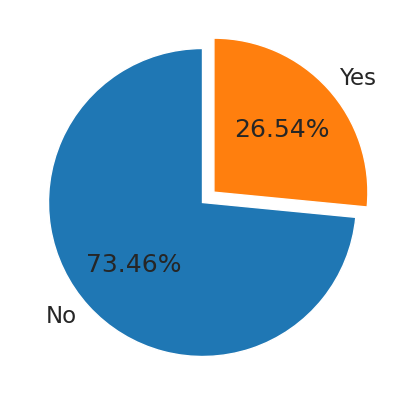

In [164]:
plt.figure(figsize=(7,5))
sizes = data.Churn.value_counts()
labels = sizes.index
plt.pie(sizes,labels=labels,  autopct='%1.2f%%', colors=colors, startangle=90, explode=(0, 0.1))
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
The target variable is imbalanced. Approximately 73.46% of customers did not churn, while 26.54% churned. This imbalance may affect model learning. Therefore, during the modeling phase, different label balancing techniques will be applied and their results will be compared.
        </li>
    </ul>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 16px;
    line-height: 1.5;    
">
Q2: What is the overall distribution of the main categorical and binary features in the dataset?


</div>

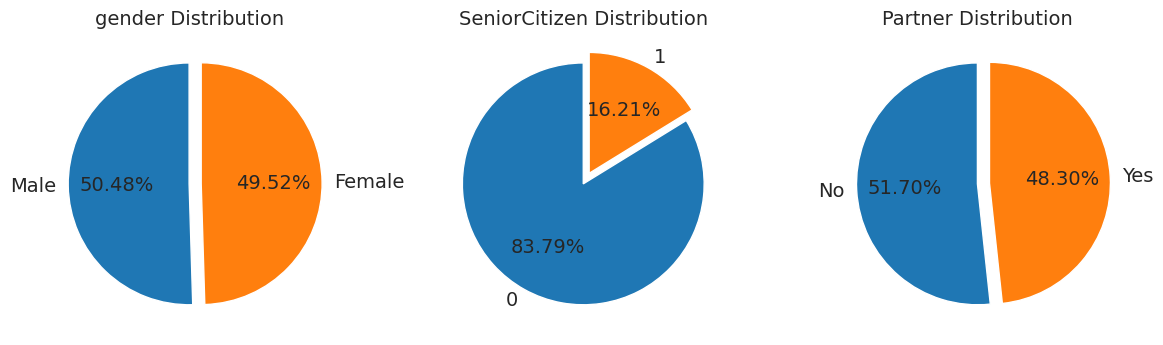

In [165]:
#part1
columns = ['gender', 'SeniorCitizen', 'Partner']
titles = ['gender', 'SeniorCitizen', 'Partner']

plt.figure(figsize=(12, 5))

for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sizes = data[col].value_counts()
    labels =sizes.index   
    plt.pie(sizes,labels=labels,  autopct='%1.2f%%', colors=colors, startangle=90,textprops={'fontsize': 14}, explode=(0, 0.1))
    plt.title(f'{col} Distribution', fontsize=14)

plt.tight_layout()
plt.show()

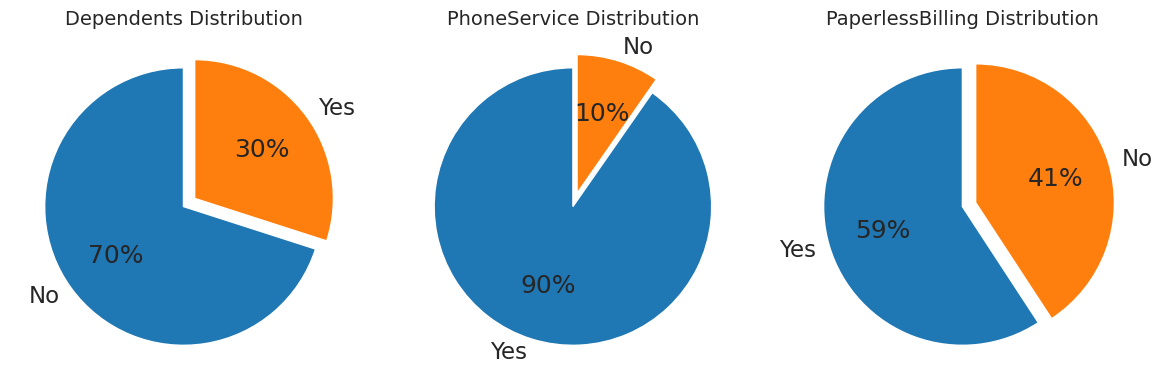

In [166]:
#part2:
columns = ['Dependents', 'PhoneService', 'PaperlessBilling']
titles = ['Dependents', 'PhoneService', 'PaperlessBilling']

plt.figure(figsize=(12, 5))

for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sizes = data[col].value_counts()
    labels =sizes.index   
    plt.pie(sizes,labels=labels,  autopct='%1.0f%%', colors=colors, startangle=90, explode=(0, 0.1))
    plt.title(f'{col} Distribution', fontsize=14)

plt.tight_layout()
plt.show()

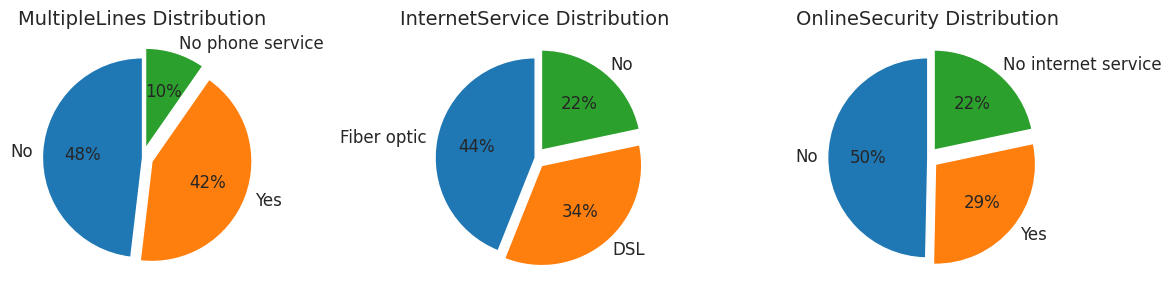

In [167]:
#part3:
columns = ['MultipleLines', 'InternetService', 'OnlineSecurity']
titles =  ['MultipleLines', 'InternetService', 'OnlineSecurity']

plt.figure(figsize=(12, 5))

for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sizes = data[col].value_counts()
    labels =sizes.index   
    plt.pie(sizes,labels=labels,  autopct='%1.0f%%', colors=colors, startangle=90,textprops={'fontsize': 12}, explode=(0, 0.1,0.1))
    plt.title(f'{col} Distribution', fontsize=14)
plt.tight_layout()
plt.show()

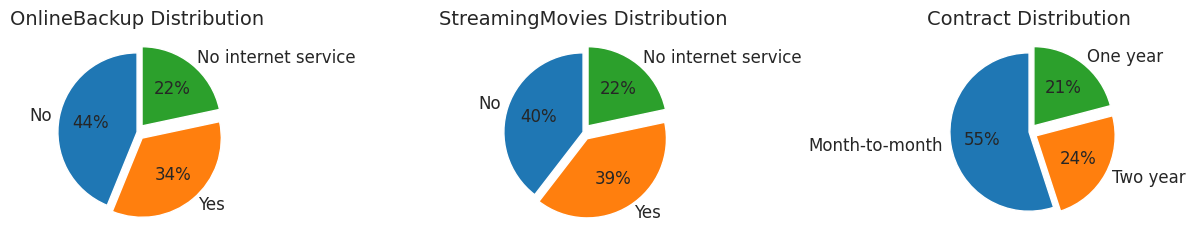

In [168]:
#part4:
columns = ['OnlineBackup', 'StreamingMovies', 'Contract']
titles = ['OnlineBackup', 'StreamingMovies', 'Contract']

plt.figure(figsize=(12, 5))

for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sizes = data[col].value_counts()
    labels =sizes.index   
    plt.pie(sizes,labels=labels,  autopct='%1.0f%%', colors=colors, startangle=90, textprops={'fontsize': 12}, explode=(0, 0.1,0.1))
    plt.title(f'{col} Distribution', fontsize=14)

plt.tight_layout()
plt.show()

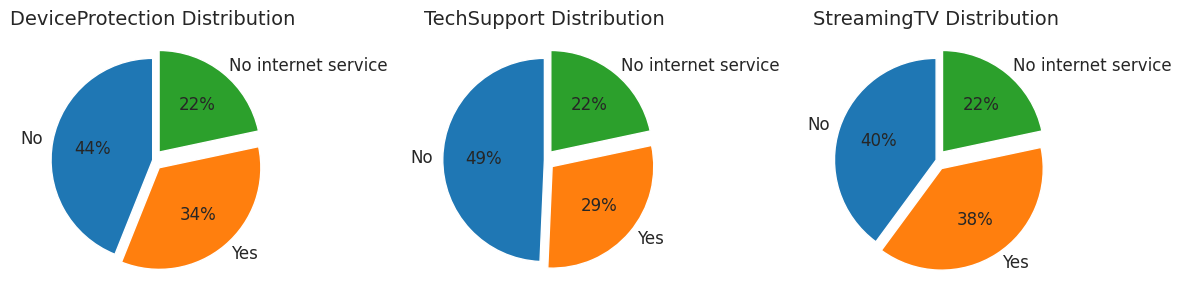

In [169]:
#part5:
columns = ['DeviceProtection', 'TechSupport', 'StreamingTV']
titles = ['DeviceProtection', 'TechSupport', 'StreamingTV']

plt.figure(figsize=(12, 5))

for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sizes = data[col].value_counts()
    labels =sizes.index   
    plt.pie(sizes,labels=labels,  autopct='%1.0f%%', colors=colors, startangle=90,textprops={'fontsize': 12}, explode=(0, 0.1,0.1))
    plt.title(f'{col} Distribution', fontsize=14)

plt.tight_layout()
plt.show()

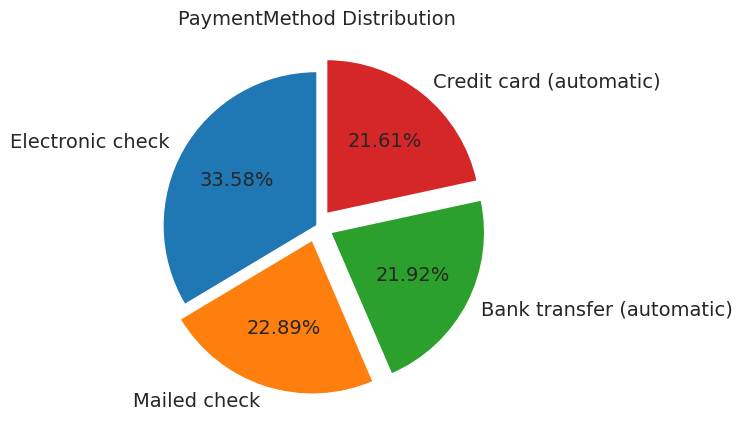

In [170]:
#part5:
plt.figure(figsize=(7,5))
sizes = data.PaymentMethod.value_counts()
labels = sizes.index
plt.pie(sizes,labels=labels,  autopct='%1.2f%%', colors=colors,textprops={'fontsize': 14}, startangle=90, explode=(0, 0.1,0.1,0.1))
plt.title(f'PaymentMethod Distribution', fontsize=14)
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
Overall, the dataset shows a diverse customer base across demographic characteristics, service usage, and billing/contract preferences. Most customers actively use core services, while a noticeable portion does not subscribe to internet-related features. In addition, short-term contracts and non-automatic payment methods are relatively common, which may have implications for customer retention behavior.
        </li>
    </ul>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 16px;
    line-height: 1.5;    
">
Q3: What is the distribution of the numerical features in the dataset?


</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
<p style="font-weight: bold; margin-bottom: 10px;">
        Tip:
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
             The TotalCharges feature is stored as an object dtype in the dataset (rather than numeric).
         </li>
           <li>       
This column contains some blank values represented as empty strings or spaces (" "), which need to be handled first.
         </li>
           <li>
            After managing these blank entries, we convert the column to a numeric type (float) to enable further analysis and modeling.
         </li>
        </ul>
</div>

In [171]:
#part1:
pattern = r' '
data.TotalCharges[data.TotalCharges.str.contains(pattern, na=False, case=False)]

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object

In [172]:
#part2:
print(f'Before: {len(data.TotalCharges[data.TotalCharges.str.contains(pattern, na=False, case=False)])}')
data = data[data['TotalCharges'].str.strip() != '']
print(f'After: {len(data.TotalCharges[data.TotalCharges.str.contains(pattern, na=False, case=False)])}')
data.TotalCharges = pd.to_numeric(data.TotalCharges, errors='coerce')
print(f'TotalCharges DataType:{data.TotalCharges.dtype} - Length:{len(data.TotalCharges)}')

Before: 11
After: 0
TotalCharges DataType:float64 - Length:7032


<Figure size 700x500 with 0 Axes>

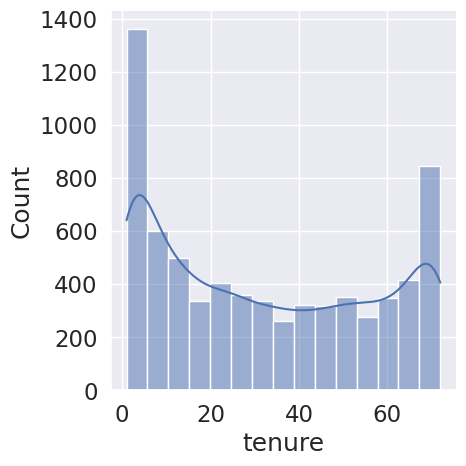

In [173]:
#Part1: Tenure:
plt.figure(figsize=(7,5))
sns.displot(data, x='tenure', kde=True)
plt.show()

<Figure size 700x500 with 0 Axes>

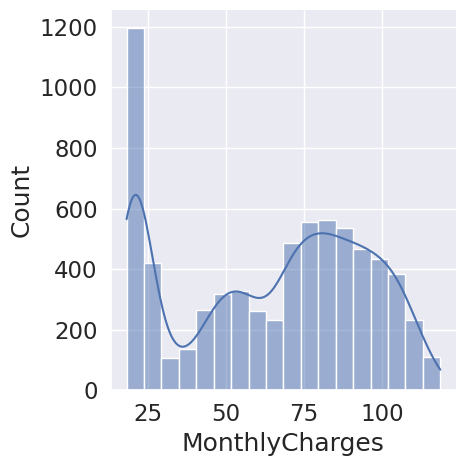

In [174]:
#Part2: MonthlyCharges:
plt.figure(figsize=(7,5))
sns.displot(data, x='MonthlyCharges', kde=True)
plt.show()

<Figure size 700x500 with 0 Axes>

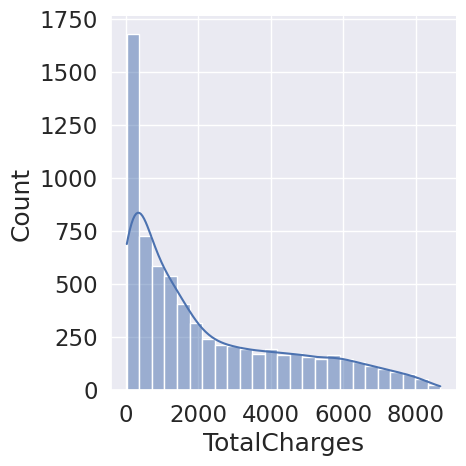

In [175]:
#Part3: TotalCharges:
plt.figure(figsize=(7,5))
sns.displot(data, x='TotalCharges', kde=True)
plt.show()

<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
            The distribution of customer tenure is bimodal: a large peak at very low values
            (many customers with 0–5 months), followed by a steady decline in the middle,
            and a second notable peak around 70–72 months (long-term loyal customers).
        </li>
        <li>
            The distribution of MonthlyCharges is multimodal with a prominent peak around 20
            (likely customers with basic or no-extra services), followed by dips and
            secondary peaks around 50–60 and 75–90, indicating clusters of customers with
            varying service bundles, before tapering off toward higher charges.
        </li>
        <li>
            The distribution of TotalCharges is heavily right-skewed with a sharp peak near 0
            (many short-tenure customers), followed by a rapid decline and a long tail
            extending to around 8,000–9,000, reflecting the cumulative effect of tenure
            and monthly charges.
        </li>
    </ul>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 16px;
    line-height: 1.5;    
">
Q4: How does customer churn rate vary across different tenure groups?
</div>

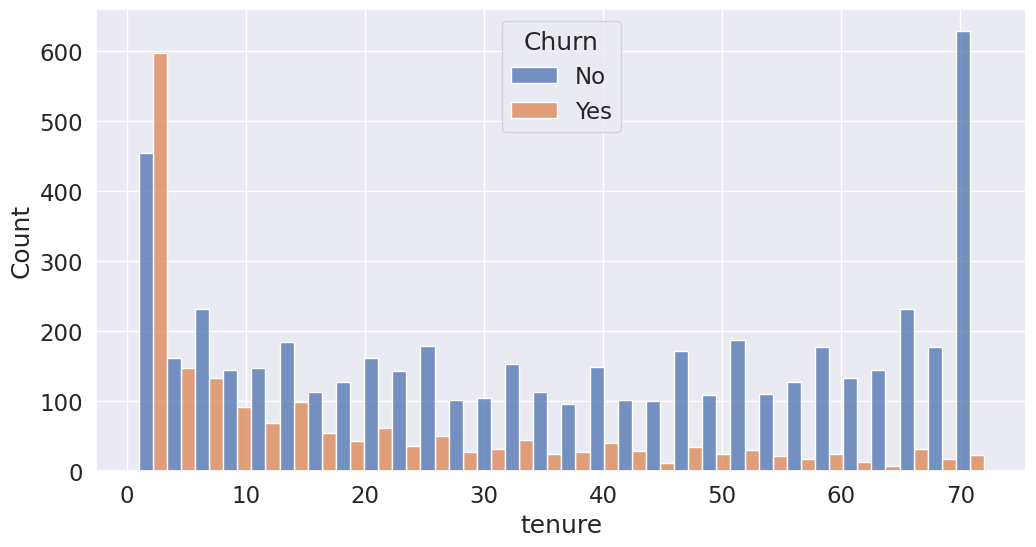

In [176]:
plt.figure(figsize=(12,6))
sns.histplot(data, x='tenure', hue='Churn', multiple='dodge', bins=30)
plt.show()

<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
Churn rate is highest among new customers (tenure < 10 months), where "Yes" bars dominate, and drops sharply as tenure increases. Long-term customers (especially around 70 months) show very low churn, with almost entirely "No" bars.
        </li>
    </ul>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 16px;
    line-height: 1.5;    
">
Q5: How does customer churn rate differ across various levels of MonthlyCharges?
</div>

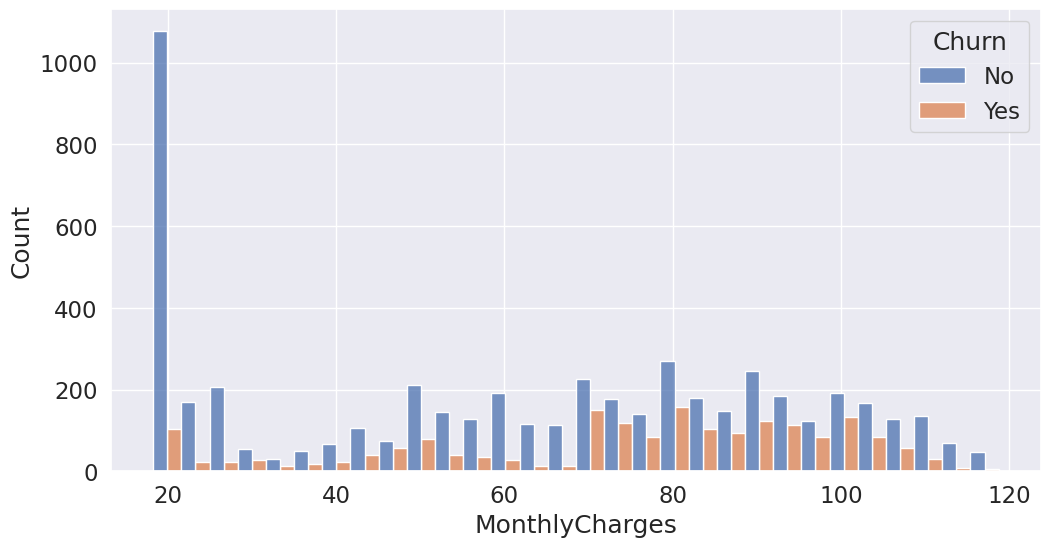

In [177]:
plt.figure(figsize=(12,6))
sns.histplot(data, x='MonthlyCharges', hue='Churn', multiple='dodge', bins=30)
plt.show()

<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
Customers with higher MonthlyCharges (above 70–80) show a noticeably higher proportion of churn (orange bars are relatively larger in that range), while low-charge customers (around 20) are mostly retained, with very little churn.
        </li>
    </ul>
</div>



<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        3. Data Preprocessing
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
<p style="font-weight: bold; margin-bottom: 10px;">
        Tip:
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
             Some of the columns have 'no internet service' or 'no phone service', that can be replaced with a simple No
         </li>
        </ul>
</div>




In [178]:
#part1
def print_unique_col_values(df):
       for column in df:
            if data[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}') 
print_unique_col_values(data)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [179]:
#part2 Change To No
data.replace('No phone service','No',inplace=True)
data.replace('No internet service','No',inplace=True)
#---
print_unique_col_values(data)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
<p style="font-weight: bold; margin-bottom: 10px;">
        Tip:
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
             
We convert binary categorical features (those with 'Yes'/'No' values) and the gender column to numeric 0/1 encoding to prepare them for modeling.
         </li>
        </ul>
</div>





In [180]:
cat_cols =['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
           'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in cat_cols:
    data[col].replace({'Yes':1, 'No':0}, inplace=True)
data.gender=data.gender.replace({'Male':1,'Female':0})

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
<p style="font-weight: bold; margin-bottom: 10px;">
        Tip:
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
Categorical features including InternetService, Contract, and PaymentMethod were encoded using one-hot encoding and then appended to the original dataset.
         </li>
        </ul>
</div>






In [181]:
cat_features = pd.get_dummies(data[['InternetService', 'Contract', 'PaymentMethod']]).astype(np.int8)
final_data=pd.concat([data,cat_features], axis=1)
final_data.drop(columns=['InternetService', 'Contract', 'PaymentMethod'], inplace=True)
display(final_data.sample(3))
print(final_data.dtypes)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2544,0,0,1,0,12,1,1,1,0,1,...,1,0,0,0,1,0,0,0,1,0
4620,1,0,1,0,72,1,1,1,1,1,...,0,1,0,0,0,1,0,1,0,0
3403,0,0,0,0,4,1,0,0,0,0,...,0,0,1,1,0,0,0,1,0,0


gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                           int8
InternetService_Fiber optic                   int8
InternetService_No             


<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
All binary features (originally 'Yes'/'No') have been successfully converted to 0/1 numeric values, categorical features have been one-hot encoded, and all columns are now in numeric format (int or float).
        </li>
    </ul>
</div>



<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
<p style="font-weight: bold; margin-bottom: 10px;">
        Tip:
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
Outliers Detection: O_O
         </li>
        </ul>
</div>

In [182]:
data[['tenure', 'MonthlyCharges', 'TotalCharges']].plot(kind='box')

<Axes: >


<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
No significant outliers were observed; however, the values need to be scaled to ensure consistency with the other features.
        </li>
    </ul>
</div>






In [183]:
#Scaling:
scale_cols=['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = MinMaxScaler()
final_data[scale_cols] = scaler.fit_transform(final_data[scale_cols])
final_data[scale_cols].sample(3)

,tenure,MonthlyCharges,TotalCharges
583,0.000000,0.007463,0.000023
4024,0.084507,0.067662,0.019750
2360,0.859155,0.017910,0.143676


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
<p style="font-weight: bold; margin-bottom: 10px;">
        Tip:
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
Correlation Coefficient:
         </li>
        </ul>
</div>

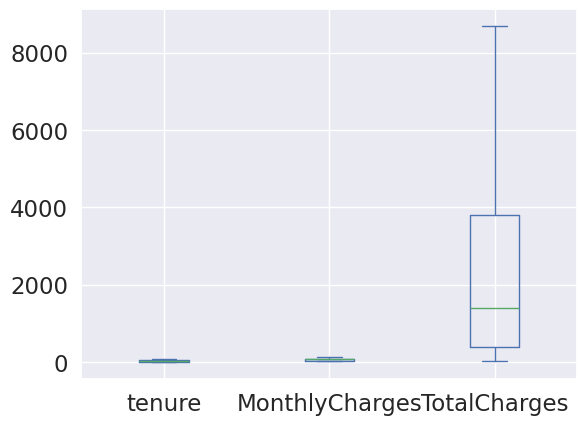

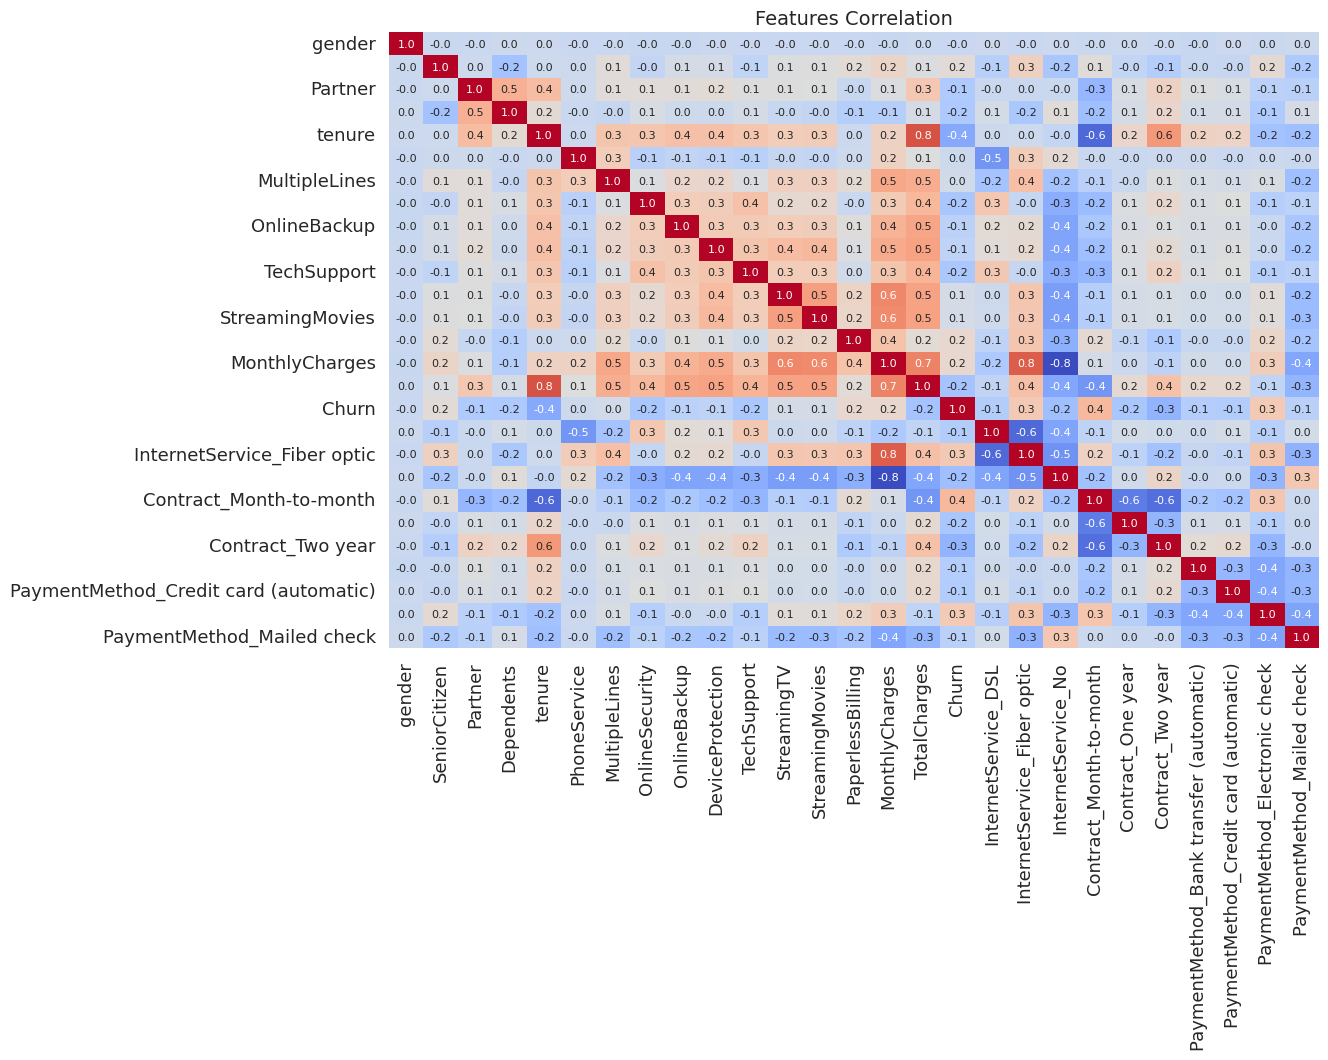

Churn                                      1.000000
Contract_Month-to-month                    0.404565
InternetService_Fiber optic                0.307463
PaymentMethod_Electronic check             0.301455
MonthlyCharges                             0.192858
PaperlessBilling                           0.191454
SeniorCitizen                              0.150541
StreamingTV                                0.063254
StreamingMovies                            0.060860
MultipleLines                              0.040033
PhoneService                               0.011691
gender                                    -0.008545
DeviceProtection                          -0.066193
OnlineBackup                              -0.082307
PaymentMethod_Mailed check                -0.090773
PaymentMethod_Bank transfer (automatic)   -0.118136
InternetService_DSL                       -0.124141
PaymentMethod_Credit card (automatic)     -0.134687
Partner                                   -0.149982
Dependents  

In [184]:
corr=final_data.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, annot_kws={'size':8}, fmt='0.1f', cbar=False, cmap='coolwarm')
plt.title('Features Correlation',fontsize=14)
plt.tick_params(axis='x',labelsize=13)
plt.tick_params(axis='y',labelsize=13)
plt.show()
print(corr.Churn.sort_values(ascending=False))


<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
The correlation heatmap shows that churn is positively associated with short-term contracts, fiber optic internet service, and electronic check payments. In contrast, longer tenure, long-term contracts, and the absence of internet service are negatively correlated with churn. Overall, customer commitment and contract duration appear to be the strongest factors related to churn behavior.
        </li>
    </ul>
</div>






<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        4. Model Building
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
<p style="font-weight: bold; margin-bottom: 10px;">
        Tip:
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
As observed earlier, the target variable (Churn) exhibits significant class imbalance. In the following steps, we will apply the SMOTE (Synthetic Minority Over-sampling Technique) method to balance the classes, ensuring more reliable modeling and evaluation.
         </li>
        </ul>
</div>

In [185]:
X = final_data.drop(columns='Churn')
y = final_data.Churn
print(f"Before: \n{y.value_counts()}")
smoth = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smoth.fit_resample(X, y)
print(f"\nAfter Using Smoth: \n{y_sm.value_counts()}")

Before: 
Churn
0    5163
1    1869
Name: count, dtype: int64

After Using Smoth: 
Churn
0    5163
1    5163
Name: count, dtype: int64


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
Spliting Data
         </li>
        </ul>
</div>

In [186]:
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2,random_state=42)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>

In the following, the dataset is evaluated using five different algorithms(Xgboost,Randon Forest, Lgbm, ExtraTrees, AdaBoost, GradientBoosting), and their outputs are analyzed.
         </li>
        </ul>
</div>

In [187]:
#part1
model_name = []
acc_train = []
recall_train = []
precision_train = []
f1_train = []
#---
acc_test = []
recall_test = []
precision_test = []
f1_test = []
time_score =[]

def model_prediction(model):
    name=str(model).split('(')[0]
    model_name.append(name)
    start_time = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics=cross_validate(estimator=model, X=X_train, y=y_train, cv=5, scoring=['accuracy', 'precision', 'recall','f1'])
    acc_train.append(round(metrics['test_accuracy'].mean(),2))
    recall_train.append(round(metrics['test_recall'].mean(),2))
    precision_train.append(round(metrics['test_precision'].mean(),2))
    f1_train.append(round(metrics['test_f1'].mean(),2))
    #----test
    acc_test.append(round(accuracy_score(y_test, y_pred),2))
    recall_test.append(round(recall_score(y_test, y_pred),2))
    precision_test.append(round(precision_score(y_test, y_pred),2))
    f1_test.append(round(f1_score(y_test, y_pred),2))
    end_time = time.time()
    time_score.append(round(end_time - start_time,4))

In [188]:
#part2
models=[XGBClassifier(), RandomForestClassifier(), LGBMClassifier(verbose=-1),
       ExtraTreesClassifier(), AdaBoostClassifier(), GradientBoostingClassifier()]
for model in tqdm(models):
    model_prediction(model)

#part3
all_models = pd.DataFrame({
    'Name':model_name,
    'Acc_Train':acc_train,
    'Precision_Train':precision_train,
    'Recall_Train':recall_train,
    'F1_Train':f1_train,
    'Acc_Test':acc_test,
    'Precision_Test':precision_test,
    'Recall_Test':recall_test,
    'F1_Test':f1_test,
    'Total_Time':time_score,
    
})
#--------------------------------------Display:
f1_train_test = ['F1_Train', 'F1_Test']
total_time = ['Total_Time']

all_models.sort_values(by='F1_Test', ascending=False).style \
  .highlight_max(subset=f1_train_test, color='#a8e6cf') \
  .highlight_min(subset=total_time, color='#ffcccb') \
  .set_properties(**{
      'border': '1px solid #ccc',
      'text-align': 'center'
  }) \
  .hide(axis='index')

  0%|          | 0/6 [00:00<?, ?it/s]

Name,Acc_Train,Precision_Train,Recall_Train,F1_Train,Acc_Test,Precision_Test,Recall_Test,F1_Test,Total_Time
XGBClassifier,0.820000,0.810000,0.850000,0.830000,0.830000,0.810000,0.840000,0.830000,0.958800
RandomForestClassifier,0.830000,0.810000,0.860000,0.840000,0.830000,0.820000,0.850000,0.830000,6.883700
ExtraTreesClassifier,0.830000,0.820000,0.860000,0.840000,0.830000,0.820000,0.850000,0.830000,5.481300
LGBMClassifier,0.820000,0.800000,0.860000,0.830000,0.820000,0.810000,0.840000,0.820000,1.034600
AdaBoostClassifier,0.790000,0.760000,0.840000,0.800000,0.790000,0.760000,0.840000,0.800000,2.827800
GradientBoostingClassifier,0.800000,0.780000,0.840000,0.810000,0.800000,0.780000,0.830000,0.800000,9.075500


<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
            Here are the approximate performance metrics of various classifiers on the SMOTE-balanced dataset (averaged over multiple runs with 5-fold cross-validation):
        </li>
        <li>
            Tree-based ensemble models (XGBClassifier, RandomForestClassifier, LGBMClassifier, and ExtraTreesClassifier) deliver strong test performance with ~85% accuracy and ~85–86% F1-score, demonstrating excellent handling of both classes.
        </li>
        <li>
            GradientBoostingClassifier (~83% test F1) and AdaBoostClassifier (~81% test F1) perform slightly lower but remain competitive.
        </li>
        <li>
            All models show only minor overfitting (train scores slightly higher than test), with small gaps indicating robust generalization after SMOTE balancing.
        </li>
        <li>
            Applying SMOTE significantly improves reliability and F1-scores—especially recall for the minority churn class—resulting in more balanced and trustworthy predictions across all models, with XGBClassifier and RandomForestClassifier consistently among the top performers.
        </li>
    </ul>
</div>



<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        5. Feature Importance: Identifying Key Drivers of Customer Churn
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
                Part1: Feature Importance (XGboost)
         </li>
        </ul>
</div>

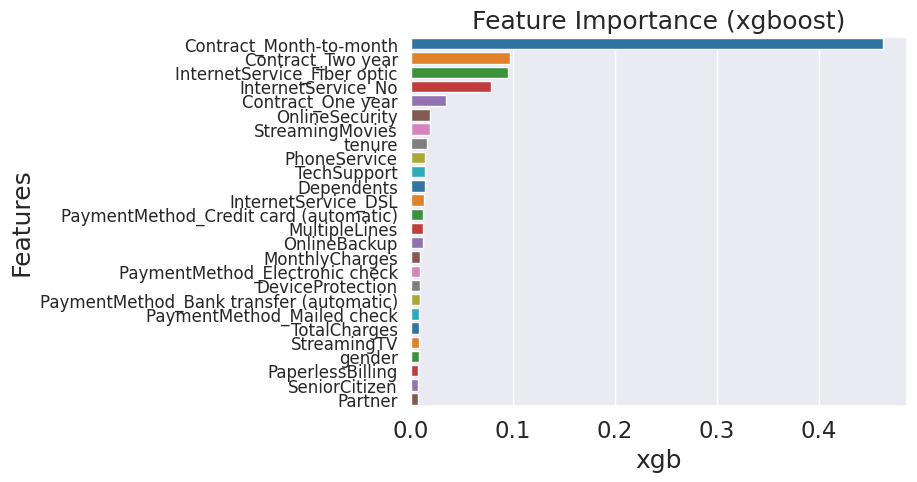

In [189]:
model = XGBClassifier()
model.fit(X_train, y_train)
feature_importance = model.feature_importances_
df_fig=pd.DataFrame({'xgb':feature_importance},index=X_train.columns)
df_fig=df_fig.sort_values(by='xgb',ascending=False)
sns.barplot(df_fig,x='xgb',y =df_fig.index, palette='tab10')
plt.ylabel('Features')
plt.title('Feature Importance (xgboost)')
plt.tick_params(axis='y',labelsize=12)
plt.show()

<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="margin-bottom: 10px;">
        The XGBClassifer  model identifies the following as the most important features driving customer churn:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
            <strong>Contract_Month-to-month</strong> (0.417) is by far the dominant predictor, indicating that short-term contracts strongly increase churn risk.
        </li>
        <li>
            Internet service type also plays a major role, with <strong>No Internet Service</strong> (0.116) and <strong>Fiber Optic</strong> (0.114) ranking high.
        </li>
        <li>
            Longer contracts provide protection against churn, as shown by <strong>Two-year Contract</strong> (0.064) and <strong>One-year Contract</strong> (0.035).
        </li>
        <li>
            Other notable contributors include <strong>StreamingMovies</strong> (0.024), <strong>OnlineSecurity</strong> (0.019), and <strong>tenure</strong> (0.017).
        </li>
    </ul>
    <p style="margin-top: 15px;">
        These results highlight that contract duration and type, along with internet service choices, are the primary drivers of customer churn, far outweighing billing amounts or demographic factors.
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
                Part2: SHAP Values: Deeper Insights into Model Predictions
         </li>
        </ul>
</div>

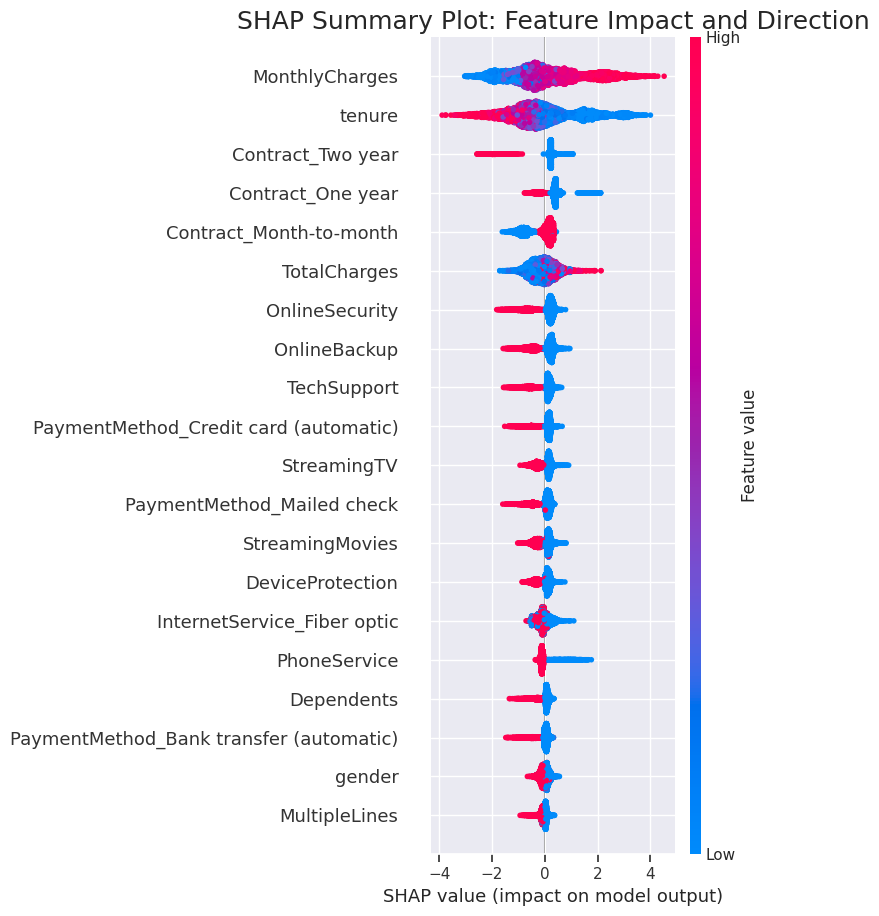

In [190]:
#summary_plot
explaner = shap.explainers.Tree(model)
shap_values = explaner(X_train)
#-----------------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train, show=False)
plt.title("SHAP Summary Plot: Feature Impact and Direction")
plt.tight_layout()
plt.show()


<div
    style="
        background-color: #F0F8FF;
        border-left: 6px solid #1E90FF;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        SHAP Summary Plot: Feature Impact and Direction
    </p>
    <p style="margin-bottom: 10px; text-align: justify;">
        This beeswarm plot provides a comprehensive view of how each feature influences the model's prediction of customer churn (higher SHAP values indicate a stronger push toward predicting churn).
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
            <strong>MonthlyCharges</strong> is the most important feature: higher monthly charges (red points on the right) strongly increase churn probability, while lower charges (blue points on the left) reduce it.
        </li>
        <li>
            <strong>tenure</strong> ranks second in importance: higher tenure values (mostly red on the negative side) significantly decrease churn risk, whereas lower tenure pushes toward churn.
        </li>
        <li>
            Contract type has a strong influence: <strong>Contract_Two year</strong> (mostly red points on the negative side) greatly reduces churn risk, while <strong>Contract_Month-to-month</strong> (blue points shifting positive) increases it. <strong>Contract_One year</strong> also shows a protective effect.
        </li>
        <li>
            Add-on services like <strong>OnlineSecurity</strong>, <strong>OnlineBackup</strong>, <strong>TechSupport</strong>, <strong>DeviceProtection</strong>, and <strong>StreamingMovies</strong> generally reduce churn probability when present (points leaning negative).
        </li>
        <li>
            Features lower in the plot (e.g., <strong>gender</strong>, <strong>MultipleLines</strong>, <strong>Dependents</strong>, payment methods, and service types) have smaller overall impact with more mixed or neutral effects.
        </li>
    </ul>
    <p style="margin-top: 15px; text-align: justify;">
        Overall, the model primarily bases its churn predictions on monthly billing amount, customer tenure, contract length (favoring long-term contracts), and the adoption of value-added services.
    </p>
</div>



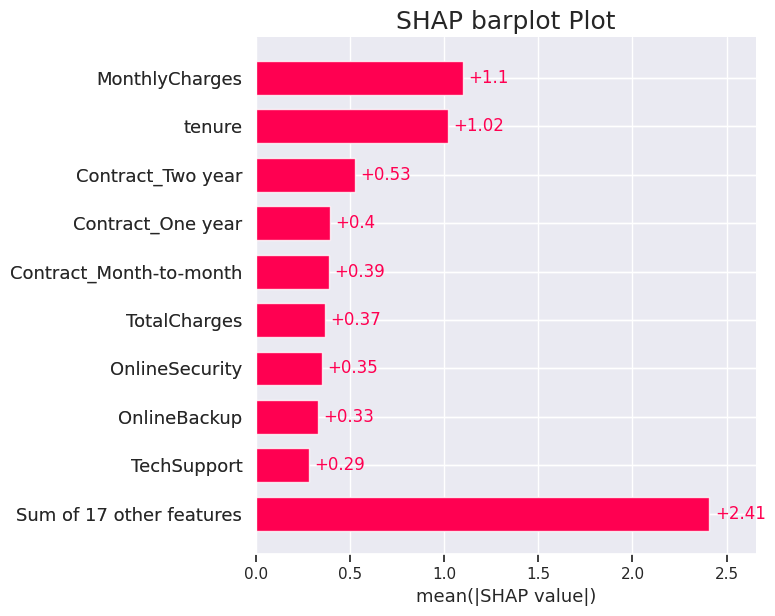

In [191]:
#barplot:
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, show=False)
plt.title("SHAP barplot Plot")
plt.tight_layout()
plt.show()


<div
    style="
        background-color: #F0F8FF;
        border-left: 6px solid #1E90FF;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        SHAP Bar Plot: Global Feature Importance
    </p>
    <p style="margin-bottom: 10px; text-align: justify;">
        This bar plot shows the global importance of each feature based on the mean absolute SHAP value — i.e., the average impact of each feature on the model's churn predictions across all customers.
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
            The combined impact of the remaining <strong>17 other features</strong> is the highest (mean |SHAP| ≈ 2.39), indicating that many lower-ranked features together contribute substantially to the model's predictions.
        </li>
        <li>
            <strong>MonthlyCharges</strong> is the most important individual feature (≈ 1.11), showing that the monthly billing amount has the strongest single influence on churn predictions.
        </li>
        <li>
            <strong>tenure</strong> ranks second among individual features (≈ 0.93), confirming customer longevity as a major driver of churn risk.
        </li>
        <li>
            Contract type features are prominent: <strong>Contract_Two year</strong> (0.50), <strong>Contract_Month-to-month</strong> (0.42), and <strong>Contract_One year</strong> (0.36) highlight the importance of contract duration.
        </li>
        <li>
            Add-on services also play a role: <strong>OnlineSecurity</strong> (0.34), <strong>TotalCharges</strong> (0.33), <strong>OnlineBackup</strong> (0.30), and <strong>TechSupport</strong> (0.26).
        </li>
    </ul>
    <p style="margin-top: 15px; text-align: justify;">
        Overall, while many features collectively drive the model, the primary individual factors for churn prediction are monthly charges, customer tenure, contract type, and selected protective add-on services.
    </p>
</div>



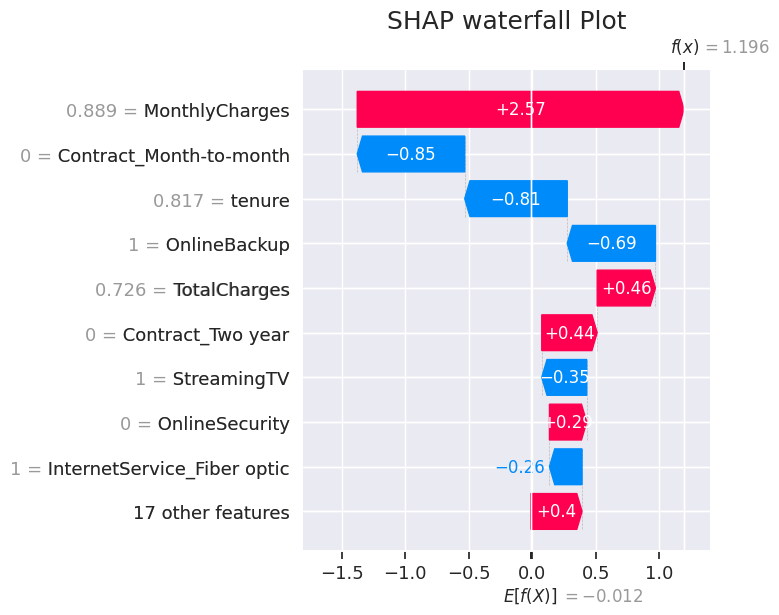

In [194]:
#waterfall:
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP waterfall Plot")
plt.tight_layout()
plt.show()

<div
    style="
        background-color: #F0F8FF;
        border-left: 6px solid #1E90FF;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        SHAP Waterfall Plot: Local Explanation for a Single Prediction
    </p>
    <p style="margin-bottom: 10px; text-align: justify;">
        This waterfall plot explains the model's prediction for one specific customer (f(x) = 5.73, indicating a very high predicted probability of churn).
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
            The base value (expected output across the dataset) is E[f(x)] ≈ -0.01.
        </li>
        <li>
            The largest positive contribution (pushing strongly toward churn) comes from <strong>low tenure</strong> (+2.57), followed by <strong>high MonthlyCharges</strong> (+0.81).
        </li>
        <li>
            Contract type also drives churn risk: having a <strong>Contract_Month-to-month</strong> (+0.40) adds positively, while the absence of longer contracts contributes smaller positive effects (+0.26 and +0.25).
        </li>
        <li>
            Some features provide negative contributions (reducing churn risk): lack of <strong>StreamingMovies</strong> (-0.45) and lack of <strong>StreamingTV</strong> (-0.15); absence of <strong>OnlineSecurity</strong> and <strong>OnlineBackup</strong> add smaller positive pushes.
        </li>
        <li>
            The remaining 17 features combined add a net +0.82 toward churn.
        </li>
    </ul>
    <p style="margin-top: 15px; text-align: justify;">
        For this customer, extremely low tenure dominates the prediction as the primary driver of high churn risk, amplified by high monthly charges, month-to-month contract, and limited protective services, leading to a strong churn prediction despite some mitigating factors.
    </p>
</div>




<div
    style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6;
    "
>
    <h2 style="text-align: center; color: #1976D2; margin-top: 0;">
        Project Summary - Key Highlights
    </h2>
    <ul style="padding-left: 25px; text-align: justify;">
        <li>
            <strong>Exploratory Data Analysis (EDA) & Visualization:</strong> Conducted thorough initial inspection, including distribution analysis of numerical features (tenure, MonthlyCharges, TotalCharges) and categorical/binary variables, with targeted visualizations to uncover patterns related to customer churn.
        </li>
        <li>
            <strong>Data Preprocessing & Feature Engineering:</strong> Cleaned the dataset by handling blank entries in TotalCharges, converted all categorical features to numeric format (binary Yes/No to 0/1, multi-category via one-hot encoding), resulting in a fully numeric dataset with no missing values.
        </li>
        <li>
            <strong>Addressing Class Imbalance:</strong> Applied SMOTE oversampling to balance the churn classes, significantly improving model reliability and F1-scores, especially recall for the minority churn class.
        </li>
        <li>
            <strong>Model Training & Evaluation:</strong> Trained and compared multiple ensemble classifiers (Random Forest, XGBoost, LightGBM, ExtraTrees, etc.) using cross-validation; tree-based models achieved strong test performance (~85% accuracy and F1-score).
        </li>
        <li>
            <strong>Model Interpretability:</strong> Utilized Random Forest feature importance and advanced SHAP analysis (bar plot, summary beeswarm plot, and waterfall plot) to identify key drivers of churn.
        </li>
        <li>
            <strong>Key Insights on Churn Drivers:</strong> The analysis revealed that low tenure, high monthly charges, month-to-month contracts, and lack of protective add-ons (e.g., OnlineSecurity, TechSupport) are the primary factors increasing churn risk, while long-term contracts and higher tenure strongly reduce it.
        </li>
    </ul>
    <p style="text-align: center; font-style: italic; margin-top: 20px; color: #555;">
        This project demonstrates a complete end-to-end pipeline for customer churn prediction, delivering both high-performing models and actionable business insights.
    </p>
</div>